Here is a plain Euler method solution for the 1-DOF damped mass-spring system with sinusoidal force.

$m\ddot{x} + c\dot{x} + kx = F_0 \sin(\omega t)$

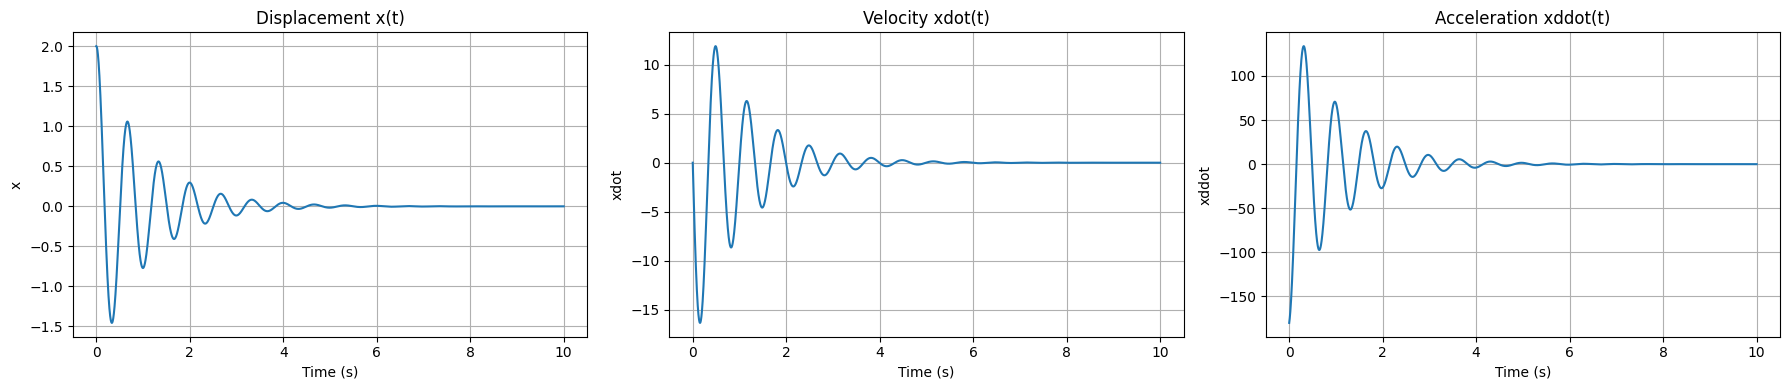

In [18]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------------
# Parameters you can change
# -----------------------------------
""""
Here, you can play with parameters, m, c, k, F0, and omega to see how they affect the system's response. 
For example, you can set m = 1.0, c = 0.0, k = 1.0 for a simple undamped harmonic oscillator, 
or you can introduce damping by setting c > 0. 
there is an interesting phenomenon called resonance that occurs when the forcing frequency (omega) is close to the natural frequency
of the system (sqrt(k/m)).
You can also experiment with different forcing frequencies (omega) to see resonance effects when omega is 
close to the natural frequency of the system (sqrt(k/m)).
to sqrt (k/m) unit is rad/s, you can convert it to Hz by dividing by 2 * pi.
Also you can adjust the initial conditions (x0 and v0) to see how they influence the transient response of the system.
Also, you can change the time settings for dt, and see how euler method behaves with different time steps, and how it affects the accuracy of the solution.
From your numerical analysis course, can we replace the Euler method with a more accurate method, such as the Runge-Kutta method, to see how it improves the results?
you can change the damping coefficient c to see how it affects the system's response. 
For example, setting c = 0 will give you an undamped system, 
while increasing c will introduce more damping and reduce the amplitude of oscillations over time.
there is a criteria for critical damping, which occurs when c = 2 * sqrt(m * k).
You can set c to this value to see how the system behaves at critical damping, where it returns to equilibrium as quickly as possible without oscillating.
You can also explore underdamped (c < 2 * sqrt(m * k)) and overdamped (c > 2 * sqrt(m * k)) cases to see how the system's response changes with different damping levels.
We define damping ratio zeta = c / (2 * sqrt(m * k)). You can set zeta to different values to see how it affects the system's response.
one more thing, did change in the forcing amplitude changes the system natural frequency? No, the natural frequency of the system is determined by the mass (m) and spring stiffness (k) and is given by sqrt(k/m).   
One last thing, it can be mathematically shown that for damped vibration, the natural frequency of the system is given by omega_d = sqrt(k/m - (c/(2*m))^2).
however, for small damping (c << 2 * sqrt(m * k)), the damped natural frequency omega_d is approximately equal to the undamped natural frequency sqrt(k/m).
which is the case for many structural systems where the damping is relatively low compared to the stiffness and mass. 

"""

#####
m = 1.0          # mass
c = 2          # damping coefficient
k = 90        # spring stiffness

#define damping ratio zeta, and calculate c from it
# zeta= 2       # damping ratio
# c = 2 * zeta * np.sqrt(m * k)  # calculate damping coefficient from damping ratio

F0 = 0         # force amplitude
omega = 3     # forcing frequency

# Time settings
dt = 0.001       # time step
t_end = 10.0     # total simulation time
n = int(t_end / dt)

# Initial conditions
x0 = 2.0         # initial displacement
v0 = 0.0         # initial velocity

# -----------------------------------
# Arrays
# -----------------------------------
t = np.zeros(n + 1)
x = np.zeros(n + 1)
v = np.zeros(n + 1)
a = np.zeros(n + 1)
f = np.zeros(n + 1)

# Set initial values
x[0] = x0
v[0] = v0
f[0] = F0 * np.sin(omega * t[0])
a[0] = (f[0] - c * v[0] - k * x[0]) / m

# -----------------------------------
# Euler method
# -----------------------------------
for i in range(n):
    t[i + 1] = t[i] + dt
    
    # External force at current time
    f[i] = F0 * np.sin(omega * t[i])
    
    # Compute acceleration from equation of motion
    a[i] = (f[i] - c * v[i] - k * x[i]) / m
    
    # Euler update
    x[i + 1] = x[i] + dt * v[i]
    v[i + 1] = v[i] + dt * a[i]

# Last force and acceleration
f[n] = F0 * np.sin(omega * t[n])
a[n] = (f[n] - c * v[n] - k * x[n]) / m

# Subplots: 1 row, 3 columns
# -----------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(t, x)
axes[0].set_title('Displacement x(t)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('x')
axes[0].grid(True)

axes[1].plot(t, v)
axes[1].set_title('Velocity xdot(t)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('xdot')
axes[1].grid(True)

axes[2].plot(t, a)
axes[2].set_title('Acceleration xddot(t)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('xddot')
axes[2].grid(True)

plt.tight_layout()
plt.show()


# 1-DOF Mass–Spring–Damper System

Consider the single degree-of-freedom (1-DOF) dynamic system

$$
m\ddot{x} + c\dot{x} + kx = f(t)
$$

where

- $m$ = mass  
- $c$ = damping coefficient  
- $k$ = stiffness  
- $x(t)$ = displacement  
- $f(t)$ = external force  

This equation describes many engineering systems such as structures, machines, and vibration systems.

---

# Free Vibration vs Forced Vibration

## Free Vibration

Free vibration occurs when **no external force acts on the system**:

$$
f(t) = 0
$$

The equation becomes

$$
m\ddot{x} + c\dot{x} + kx = 0
$$

The motion is caused only by the **initial displacement** and/or **initial velocity**.

### Undamped Free Vibration

If there is **no damping**,

$$
c = 0
$$

the equation becomes

$$
m\ddot{x} + kx = 0
$$

The system oscillates forever with constant amplitude.

### Damped Free Vibration

If damping exists,

$$
c > 0
$$

the oscillations gradually decay over time.

---

## Forced Vibration

Forced vibration occurs when an **external force acts on the system**:

$$
f(t) \neq 0
$$

The response depends on the characteristics of the applied force.

Common types of excitation include:

- **Periodic loading**

$$
f(t) = F_0 \sin(\omega t)
$$

- **Random loading**  
  Examples: wind, turbulence, earthquakes

- **Impact loading**  
  Sudden short-duration forces such as hammer strikes

- **Combined loading**  
  A combination of multiple force types acting simultaneously

---

# Natural Frequency

The **undamped natural frequency** depends only on the system properties:

$$
\omega_n = \sqrt{\frac{k}{m}}
$$

Units: rad/s

Convert to frequency in Hz:

$$
f_n = \frac{\omega_n}{2\pi}
$$

Important notes:

- Changing force amplitude does **not** change the natural frequency
- Natural frequency depends only on **mass** and **stiffness**

---

# Damping Ratio

The damping ratio measures how quickly oscillations decay:

$$
\zeta = \frac{c}{2\sqrt{km}}
$$

Typical structural systems have

$$
\zeta \approx 0.01 - 0.05
$$

which indicates **light damping**.

---

# Types of Damping Behavior

## Underdamped

$$
c < 2\sqrt{mk}
$$

or equivalently

$$
\zeta < 1
$$

Characteristics:

- Oscillatory motion
- Amplitude decays gradually

This is the most common case in structural dynamics.

## Critically Damped

$$
c = 2\sqrt{mk}
$$

or

$$
\zeta = 1
$$

Characteristics:

- Fastest return to equilibrium
- No oscillations

## Overdamped

$$
c > 2\sqrt{mk}
$$

or

$$
\zeta > 1
$$

Characteristics:

- No oscillations
- Slow return to equilibrium

---

# Damped Natural Frequency

When damping exists, the oscillation frequency becomes

$$
\omega_d = \sqrt{\frac{k}{m} - \left(\frac{c}{2m}\right)^2}
$$

or equivalently

$$
\omega_d = \omega_n\sqrt{1-\zeta^2}
$$

For lightly damped systems,

$$
\omega_d \approx \omega_n
$$

which is usually true for many structural systems.

---

# Resonance

Resonance occurs when the forcing frequency approaches the natural frequency:

$$
\omega \approx \omega_n
$$

Effects:

- Large vibration amplitudes
- Strong dynamic response

Damping reduces the resonance peak.

---

# System Properties

## Linear System

A system is **linear** if it satisfies:

- proportionality
- superposition

If

$$
f_1(t) \rightarrow x_1(t)
$$

and

$$
f_2(t) \rightarrow x_2(t)
$$

then

$$
f_1(t) + f_2(t) \rightarrow x_1(t) + x_2(t)
$$

The mass-spring-damper model is linear when $m$, $c$, and $k$ are constants.

---

## Time-Invariant System

A system is **time-invariant** if its properties do not change with time.

That means:

- $m$, $c$, and $k$ are constant
- the governing equation is the same at all times

If the input is delayed, the output is delayed by the same amount.

---

## Stationary Process

A process is **stationary** when its statistical properties remain constant over time.

For example:

- constant mean
- constant variance
- unchanged probability distribution over time

Stationarity is important in **random vibration** and **signal processing**.

---

# Numerical Simulation Considerations

When solving the equation numerically:

- **Euler method** is simple but less accurate
- Smaller time step $dt$ improves accuracy
- More accurate methods include:
  - **Runge-Kutta methods**
  - **Newmark methods**

Newmark methods are widely used in structural dynamics.